This code will be used strictly for evaulation purposes for all the models that I have run. 

In [7]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker

This will take in all the predictions from the various models

In [ ]:
#bringing in the new data. 

In [8]:
#ITCZ data: 
predictions_model1_africa = xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/variable_shuffle/Africa_Predictions_NoTotPrecip.nc")
africa_flash_MTG = xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/Data_Folder_All/Features/Africa_new/MTG_africa.nc")
africa_lopez = xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/Data_Folder_All/Features/Africa_new/Lopez_africa.nc")

This next block will take in the GLM test set as well as the Lopez output

This is to unlogg all the predictions so we are comparing the same scales of flashes

In [9]:
#Unlog the Data
model1_unlogged_africa = (10**(predictions_model1_africa['predicted_flashes'])) - 1 
#actual_unlogged_pacific = (10**(pacific_flash_test['flashes_log'])) - 1

In [10]:
africa_lopez = africa_lopez['Lopez_flashes'] * 0.836979

In [101]:
# # Slicing from the start of June to the end of July
# regression_JJ = model1_unlogged_pacific.sel(Datetime=slice('2024-06-01', '2024-07-31'))
# NOCAPE_JJ = model2_unlogged_pacific.sel(Datetime=slice('2024-06-01', '2024-07-31'))
# NOMSE_JJ = model3_unlogged_pacific.sel(Datetime=slice('2024-06-01', '2024-07-31'))
# NOIceFlux_JJ = model4_unlogged_pacific.sel(Datetime=slice('2024-06-01', '2024-07-31'))
# glm_JJ = actual_unlogged_pacific.sel(Datetime=slice('2024-06-01', '2024-07-31'))
# lopez_JJ = pacific_lopez_test.sel(Datetime=slice('2024-06-01', '2024-07-31'))

# regression_ON = model1_unlogged_pacific.sel(Datetime=slice('2024-10-01', '2024-11-30'))
# NOCAPE_ON = model2_unlogged_pacific.sel(Datetime=slice('2024-10-01', '2024-11-30'))
# NOMSE_ON = model3_unlogged_pacific.sel(Datetime=slice('2024-10-01', '2024-11-30'))
# NOIceFlux_ON = model4_unlogged_pacific.sel(Datetime=slice('2024-10-01', '2024-11-30'))
# glm_ON = actual_unlogged_pacific.sel(Datetime=slice('2024-10-01', '2024-11-30'))
# lopez_ON = pacific_lopez_test.sel(Datetime=slice('2024-10-01', '2024-11-30'))

In [11]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 13,

    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.titlepad": 10,

    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    "axes.linewidth": 1.2,
    "xtick.major.width": 1.1,
    "ytick.major.width": 1.1,
    "xtick.major.size": 6,
    "ytick.major.size": 6,

    "legend.fontsize": 11,
})

Total Africa Domain Area: 12,497,139.76 km²


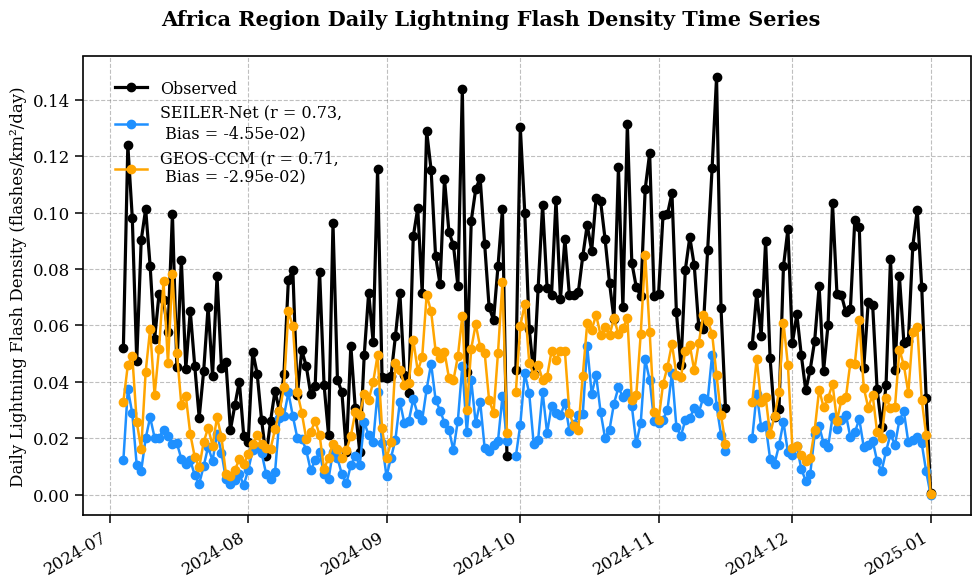

In [6]:
#Seasonal Variability 
from scipy.stats import pearsonr

# ==============================================================================
# 1. CALCULATE EXACT 0.5° AFRICA DOMAIN AREA (Matching Spatial Heatmap)
# ==============================================================================
# Bounds: [8, 40, -16, 16] -> 64x64 grid cells at 0.5° resolution
lats_05 = np.linspace(-15.75, 15.75, 64)
lons_05 = np.linspace(8.25, 39.75, 64)

dlat_rad = np.radians(0.5)
dlon_rad = np.radians(0.5)
R = 6371.0  # Earth's radius in km

# Spherical grid cell areas
lat_centers_rad = np.radians(lats_05)
cell_areas_km2 = (
    (R**2)
    * dlon_rad
    * (
        np.sin(lat_centers_rad + dlat_rad / 2)
        - np.sin(lat_centers_rad - dlat_rad / 2)
    )
)
grid_areas_2d = np.tile(cell_areas_km2[:, np.newaxis], (1, len(lons_05)))

# Total Africa domain surface area in km²
domain_area_km2 = grid_areas_2d.sum()
print(f"Total Africa Domain Area: {domain_area_km2:,.2f} km²")


# ==============================================================================
# 2. DATA PROCESSING & TEMPORAL RESAMPLING
# ==============================================================================
datetimes_Africa = pd.to_datetime(africa_flash_MTG["Datetime"].values)

# --- Extract spatial observations array safely ---
if "flashes" in africa_flash_MTG:
    actual_data_array = africa_flash_MTG["flashes"]
else:
    actual_data_array = africa_flash_MTG

# 1. Spatial Sum (Total flashes per hour over the whole Africa domain)
m1_spatial_sum = model1_unlogged_africa.sum(dim=("Latitudes", "Longitudes")).squeeze()
actual_spatial_sum = actual_data_array.sum(dim=("Latitudes", "Longitudes")).squeeze()
lopez_spatial_sum = africa_lopez.sum(dim=("Latitudes", "Longitudes")).squeeze()

# 2. Temporal Resample (Total flashes per day over the whole domain)
daily_m1 = pd.Series(m1_spatial_sum.values, index=datetimes_Africa).resample("D").sum()
daily_actual = pd.Series(actual_spatial_sum.values, index=datetimes_Africa).resample("D").sum()
daily_lopez = pd.Series(lopez_spatial_sum.values, index=datetimes_Africa).resample("D").sum()

# 3. Mask Zero-Flash Days as NaN for clean plot breaks
zero_days = daily_actual == 0
daily_actual[zero_days] = np.nan
daily_m1[zero_days] = np.nan
daily_lopez[zero_days] = np.nan

# 4. Convert Total Daily Flashes -> Daily Flash Density (flashes/km²/day)
daily_actual_density = daily_actual / domain_area_km2
daily_pred_density = daily_m1 / domain_area_km2
daily_lopez_density = daily_lopez / domain_area_km2


# ==============================================================================
# 3. METRICS CALCULATION
# ==============================================================================
valid_mask = ~daily_actual_density.isna()

r1, _ = pearsonr(
    daily_pred_density[valid_mask].values, daily_actual_density[valid_mask].values
)
rlopez, _ = pearsonr(
    daily_lopez_density[valid_mask].values, daily_actual_density[valid_mask].values
)

# Mean Bias (flashes/km²/day)
bias1 = (daily_pred_density - daily_actual_density).mean()
blopez = (daily_lopez_density - daily_actual_density).mean()


# ==============================================================================
# 4. PLOTTING THE SINGLE-PANEL FIGURE
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 6))

# --- Plot Observed ---
ax.plot(
    daily_actual_density.index,
    daily_actual_density.values,
    marker="o",
    linewidth=2.3,
    color="black",
    label="Observed",
)

# --- Plot SEILER-Net ---
ax.plot(
    daily_pred_density.index,
    daily_pred_density.values,
    marker="o",
    linewidth=1.8,
    color="dodgerblue",
    label=f"SEILER-Net (r = {r1:.2f},\n Bias = {bias1:+.2e})",
)

# --- Plot GEOS-CCM ---
ax.plot(
    daily_lopez_density.index,
    daily_lopez_density.values,
    marker="o",
    linewidth=1.8,
    color="orange",
    label=f"GEOS-CCM (r = {rlopez:.2f},\n Bias = {blopez:+.2e})",
)

# --- Labeling and Legends ---
ax.set_ylabel("Daily Lightning Flash Density (flashes/km²/day)", fontsize=12)
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.98),
    fontsize=11.5,
)

# ==============================================================================
# 5. GLOBAL REFINEMENTS & FORMATTING
# ==============================================================================
ax.tick_params(axis="x", rotation=30, labelsize=12)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

# Format Y-axis with scientific notation
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.ticklabel_format(style="scientific", axis="y", scilimits=(-3, 3))
ax.tick_params(axis="y", labelsize=12, direction="out")
ax.grid(True, linestyle="--", alpha=0.5, color="gray")

for spine in ax.spines.values():
    spine.set_visible(True)

# Main Title
fig.suptitle(
    "Africa Region Daily Lightning Flash Density Time Series",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout()

#Save high-resolution PDF
plt.savefig(
    "Africa_Lightning_Time_Series_Final.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

This will be a time series of hourly flashes for each period. This will be for diurnal checks. 

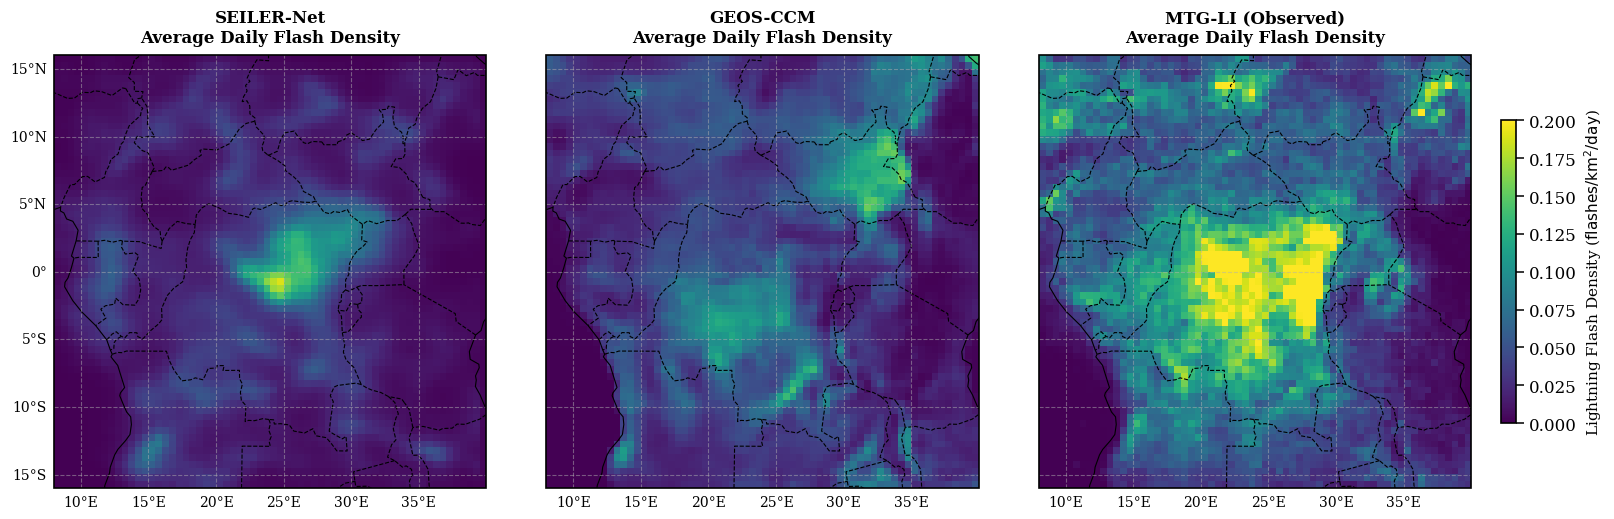

In [14]:

# ------------------------------------------------------------------------------
# 1. Setup Models & Explicit 0.5° Domain Coordinates
# ------------------------------------------------------------------------------
models = [
    model1_unlogged_africa,
    africa_lopez,
    (
        africa_flash_MTG["flashes"]
        if "flashes" in africa_flash_MTG
        else africa_flash_MTG
    ),
]
model_names = ["SEILER-Net", "GEOS-CCM", "MTG-LI (Observed)"]

extent_africa = [8, 40, -16, 16]

# 64 grid cell centers spanning -16° to 16° Lat and 8° to 40° Lon
lats_05 = np.linspace(-15.75, 15.75, 64)
lons_05 = np.linspace(8.25, 39.75, 64)

# ------------------------------------------------------------------------------
# 2. Calculate True 0.5° x 0.5° Cell Areas (km²)
# ------------------------------------------------------------------------------
dlat_rad = np.radians(0.5)
dlon_rad = np.radians(0.5)
R = 6371.0  # Earth's radius in kilometers

lat_centers_rad = np.radians(lats_05)
cell_areas_km2 = (
    (R**2)
    * dlon_rad
    * (
        np.sin(lat_centers_rad + dlat_rad / 2)
        - np.sin(lat_centers_rad - dlat_rad / 2)
    )
)
# Shape (64, 64) area matrix
grid_areas_2d = np.tile(cell_areas_km2[:, np.newaxis], (1, len(lons_05)))

# ------------------------------------------------------------------------------
# 3. Compute Flash Density (flashes / km² / day)
# ------------------------------------------------------------------------------
densities = []

for model in models:
    total_timesteps = len(model["Datetime"])
    total_days = total_timesteps / 24.0

    total_flashes_per_cell = model.sum(dim="Datetime").squeeze().values
    daily_flashes_per_cell = total_flashes_per_cell / total_days

    # Divide by accurate 0.5° grid area
    density = daily_flashes_per_cell / grid_areas_2d
    densities.append(density)

# ------------------------------------------------------------------------------
# 4. Figure & Plot Setup (1 Row, 3 Columns)
# ------------------------------------------------------------------------------
# Set vmax to 0.30 to accommodate Central Africa's peak convection
vmax_val = 0.20

fig, axes = plt.subplots(
    1, 3, figsize=(16, 5), subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.set_layout_engine(layout="constrained", w_pad=0.0, h_pad=0.0)

mesh = None

for idx, (density, name, ax) in enumerate(zip(densities, model_names, axes)):
    # Map features
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.8)
    ax.add_feature(
        cfeature.BORDERS.with_scale("110m"), linestyle="--", linewidth=0.8
    )

    ax.set_extent(extent_africa, crs=ccrs.PlateCarree())

    mesh = ax.imshow(
        density,
        extent=extent_africa,
        origin="lower",
        cmap="viridis",
        vmin=0.0,
        vmax=vmax_val,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(
        f"{name}\nAverage Daily Flash Density",
        fontsize=12,
        fontweight="bold",
    )

    # Gridlines setup
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    if idx > 0:
        gl.left_labels = False

    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

# ------------------------------------------------------------------------------
# 5. Shared Colorbar
# ------------------------------------------------------------------------------
cbar = fig.colorbar(mesh, ax=axes, shrink=0.70, pad=0.02, location="right")
cbar.set_label(
    r"Lightning Flash Density ($\text{flashes/km}^2/\text{day}$)",
    fontsize=11,
)

plt.savefig(
    "Africa_Flash_Density_Final.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

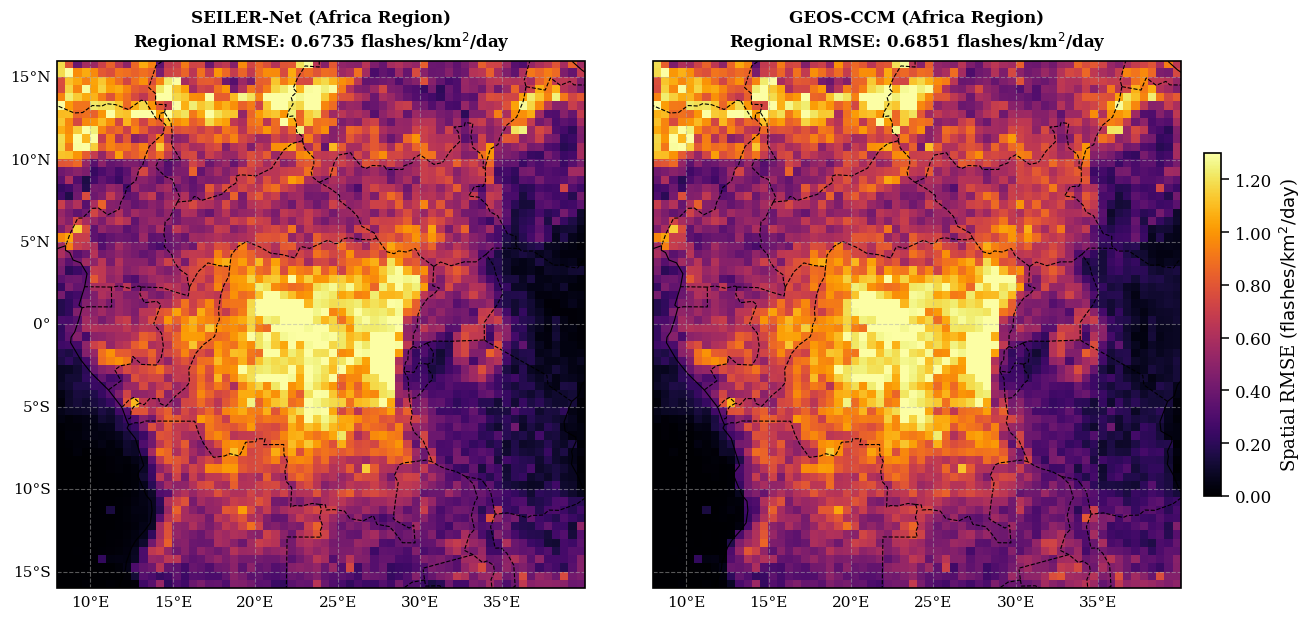

In [18]:
# import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ==============================================================================
# 1. SETUP MODELS AND REFERENCE (AFRICA DATASETS)
# ==============================================================================
models = [model1_unlogged_africa, africa_lopez]
model_names = ["SEILER-Net", "GEOS-CCM"]

# Explicitly isolate reference array
actual_data = (
    africa_flash_MTG["flashes"]
    if "flashes" in africa_flash_MTG
    else africa_flash_MTG
)

# ==============================================================================
# 2. SETUP THE MULTI-PANEL GRID (1 Row, 2 Columns)
# ==============================================================================
fig, axes = plt.subplots(
    1, 2, figsize=(13, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.set_layout_engine(layout="constrained", w_pad=0.0, h_pad=0.0)

extent_africa = [8, 40, -16, 16]

# Unscaled max limit in flashes/km²/day (Adjust if necessary, e.g., 0.10 or 0.12)
vmax_val = 1.3
im = None

# ==============================================================================
# 3. LOOP THROUGH AND COMPUTE SPATIAL RMSE
# ==============================================================================
for idx, (model_data, name, ax) in enumerate(zip(models, model_names, axes)):

    # --- 3a. Spherical Grid Cell Area Calculation ---
    lat_coords = model_data["Latitudes"].values
    lon_coords = model_data["Longitudes"].values

    dlat_rad = np.radians(abs(lat_coords[1] - lat_coords[0]))
    dlon_rad = np.radians(abs(lon_coords[1] - lon_coords[0]))
    R = 6371.0  # Earth's radius in km

    lat_centers_rad = np.radians(lat_coords)
    cell_areas_km2 = (
        (R**2)
        * dlon_rad
        * (
            np.sin(lat_centers_rad + dlat_rad / 2)
            - np.sin(lat_centers_rad - dlat_rad / 2)
        )
    )

    # Broadcast to DataArray matching model Latitudes to preserve xarray metadata
    grid_areas = model_data["Latitudes"] * 0 + cell_areas_km2

    # --- 3b. Convert to Daily Rate (flashes/km²/day) using xarray math ---
    # xarray automatically handles dimension alignment across (Datetime, Lat, Lon)
    model_daily_rate = (model_data * 24.0) / grid_areas
    actual_daily_rate = (actual_data * 24.0) / grid_areas

    # --- 3c. Calculate Spatial Grid RMSE using xarray math ---
    squared_error = (model_daily_rate - actual_daily_rate) ** 2

    # Mean over the Datetime dimension
    mean_squared_error = squared_error.mean(dim="Datetime")
    spatial_rmse_map = np.sqrt(mean_squared_error.values)

    # Calculate global domain RMSE score
    global_rmse = np.sqrt(squared_error.mean().values)

    # --- 3d. Add Geographic Map Elements ---
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.8)
    ax.add_feature(
        cfeature.BORDERS.with_scale("110m"), linestyle="--", linewidth=0.8
    )

    ax.set_extent(extent_africa, crs=ccrs.PlateCarree())

    # --- 3e. Display Error Map ---
    im = ax.imshow(
        spatial_rmse_map,
        extent=extent_africa,
        origin="lower",
        cmap="inferno",
        vmin=0,
        vmax=vmax_val,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(
        f"{name} (Africa Region)\nRegional RMSE: {global_rmse:.4f} flashes/km$^2$/day",
        fontsize=12,
        fontweight="bold",
    )

    # --- 3f. Configure Gridlines ---
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    if idx > 0:
        gl.left_labels = False

    gl.xlabel_style = {"size": 11}
    gl.ylabel_style = {"size": 11}

# ==============================================================================
# 4. COLORBAR AND EXPORT
# ==============================================================================
cbar = fig.colorbar(im, ax=axes, shrink=0.65, pad=0.02, location="right")

cbar.formatter = mticker.FormatStrFormatter("%.2f")
cbar.update_ticks()

cbar.set_label(
    r"Spatial RMSE ($\text{flashes/km}^2/\text{day}$)", fontsize=13
)

plt.savefig(
    "Africa_spatial_RMSE_Final.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

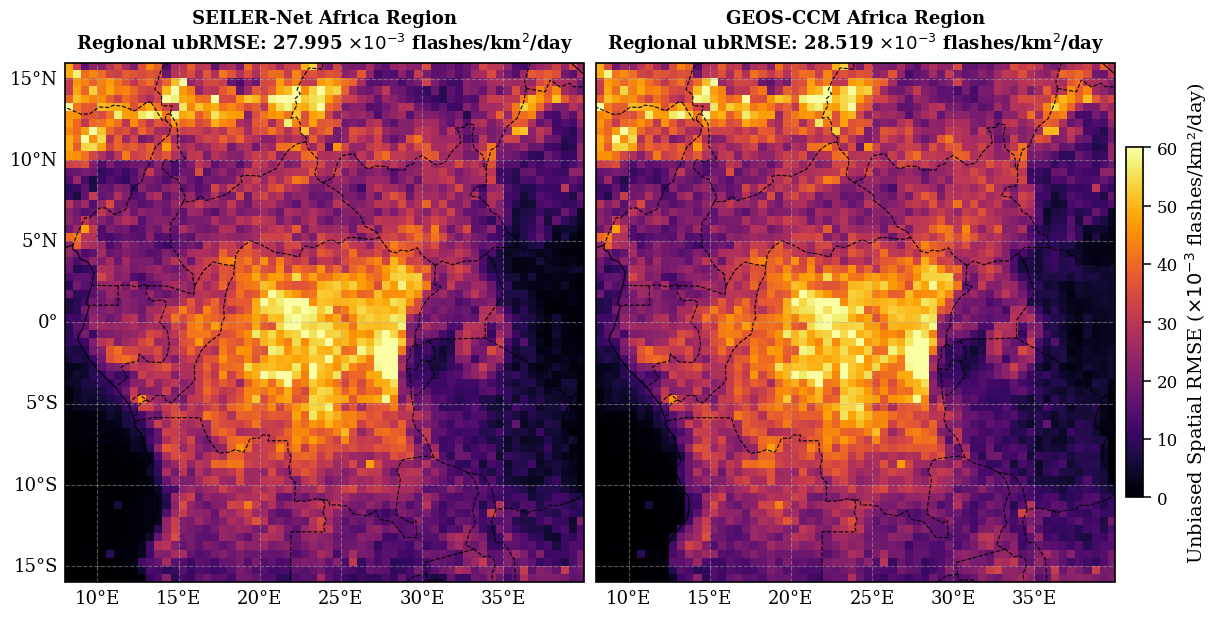

In [8]:
models = [
    model1_unlogged_africa,
    africa_lopez
]
model_names = ["SEILER-Net", "GEOS-CCM"]

# Explicitly isolate the actual reference array
actual_data = africa_flash_MTG['flashes'] if 'flashes' in africa_flash_MTG else africa_flash_MTG

# ==============================================================================
# 2. SETUP THE MULTI-PANEL GRID (1 Row, 2 Columns)
# ==============================================================================
fig, axes = plt.subplots(
    1, 2, 
    figsize=(12, 6), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)

fig.set_layout_engine(layout="constrained", w_pad=0.0, h_pad=0.0)

extent_africa = [8, 40, -16, 16]

# Lower vmax slightly since removing bias reduces total error values
vmax_val = 60.0  
im = None

# ==============================================================================
# 3. LOOP THROUGH AND COMPUTE UNBIASED SPATIAL RMSE (ubRMSE)
# ==============================================================================
for idx, (model_data, name, ax) in enumerate(zip(models, model_names, axes)):
    
    # --- 3a. Extract Lat/Lon Dimensions and calculate spherical grid cell areas ---
    lat_coords = model_data["Latitudes"].values
    lon_coords = model_data["Longitudes"].values
    
    dlat_rad = np.radians(abs(lat_coords[1] - lat_coords[0]))
    dlon_rad = np.radians(abs(lon_coords[1] - lon_coords[0]))
    R = 6371.0  
    
    lat_centers_rad = np.radians(lat_coords)
    cell_areas_km2 = (R**2) * dlon_rad * (
        np.sin(lat_centers_rad + dlat_rad / 2) - np.sin(lat_centers_rad - dlat_rad / 2)
    )
    
    # Keep grid_areas as an xarray DataArray so it seamlessly aligns with the models
    grid_areas = model_data["Latitudes"] * 0 + cell_areas_km2
    
    # --- 3b. Convert BOTH arrays using xarray native math ---
    model_density_scaled = (model_data / grid_areas) * 1000
    actual_density_scaled = (actual_data / grid_areas) * 1000
    
    # --- 3c. Calculate Unbiased Spatial RMSE (Removing Mean Bias) ---
    # 1. Compute raw temporal residual time-series per cell
    raw_residual = model_density_scaled - actual_density_scaled
    
    # 2. Compute 2D spatial mean bias map
    mean_bias_map = raw_residual.mean(dim="Datetime")
    
    # 3. Subtract each cell's mean bias over time (xarray automatically broadcasts 2D onto 3D)
    centered_residual = raw_residual - mean_bias_map
    
    # 4. Compute Unbiased RMSE per grid cell
    unbiased_mse = (centered_residual ** 2).mean(dim="Datetime")
    spatial_ubrmse_map = np.sqrt(unbiased_mse.values)
    
    # 5. Global Domain-Wide Unbiased RMSE score
    # Subtraction of the total spatio-temporal mean error
    global_centered_residual = raw_residual - raw_residual.mean()
    global_ubrmse = np.sqrt((global_centered_residual ** 2).mean().values)
    
    # --- 3d. Add Geographic Map Elements ---
    ax.add_feature(cfeature.COASTLINE.with_scale('110m'), linewidth=0.8)
    ax.add_feature(cfeature.STATES.with_scale('110m'), linewidth=0.5, edgecolor='black')
    ax.add_feature(cfeature.BORDERS.with_scale('110m'), linestyle='--', linewidth=0.8)
    
    ax.set_extent(extent_africa, crs=ccrs.PlateCarree())
    
    # --- 3e. Display Unbiased Error Map ---
    im = ax.imshow(
        spatial_ubrmse_map,
        extent=extent_africa,
        origin="lower",
        cmap="inferno",  
        vmin=0,
        vmax=vmax_val,
        transform=ccrs.PlateCarree()
    )
    
    ax.set_title(
        f"{name} Africa Region\nRegional ubRMSE: {global_ubrmse:.3f} " + r"$\times 10^{-3}$ flashes/km$^2$/day", 
        fontsize=13, 
        fontweight='bold'
    )
    
    # --- 3f. Configure Gridlines ---
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    if idx > 0:
        gl.left_labels = False
        
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}

# ==============================================================================
# 4. COLORBAR AND EXPORT
# ==============================================================================
cbar = fig.colorbar(im, ax=axes, shrink=0.6, pad=0.01, location="right")

cbar.formatter = mticker.FormatStrFormatter('%d')
cbar.update_ticks()

cbar.set_label(r"Unbiased Spatial RMSE ($\times 10^{-3}$ flashes/km²/day)", fontsize=14)

# plt.savefig(
#     "Africa_spatial_Unbiased_RMSE_comparison.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=False,
# )

plt.show()

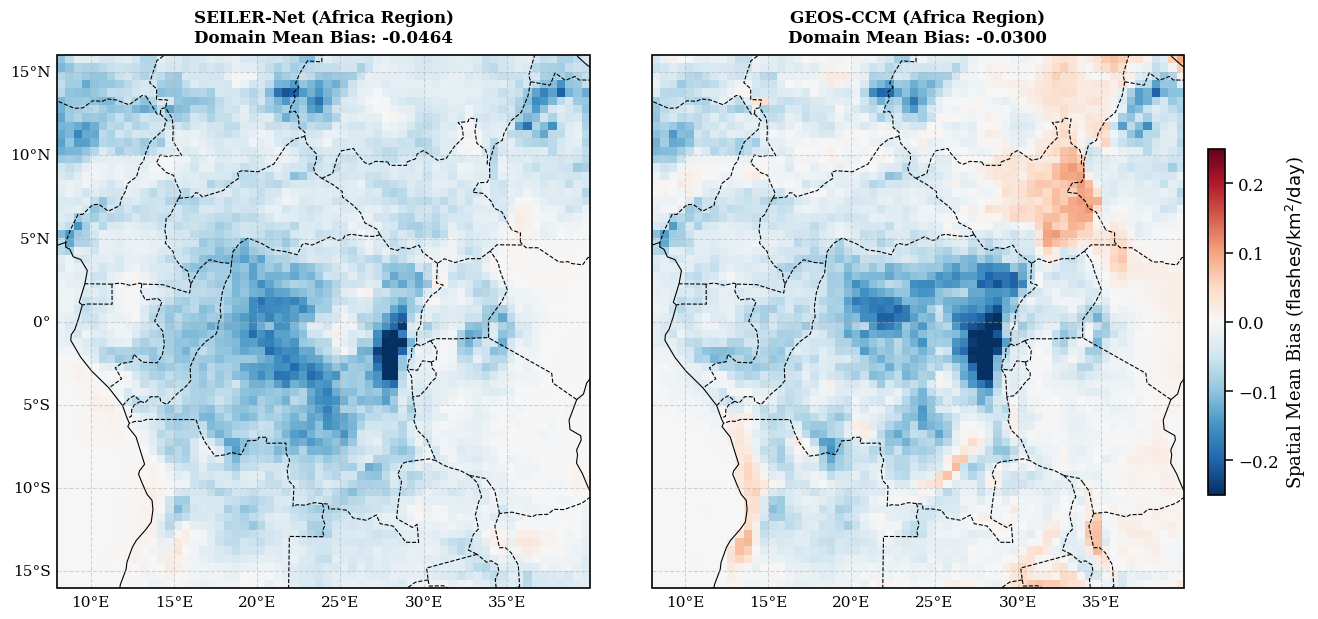

In [18]:
#African Bias Plot
#==========================================================
# 1. SETUP DOMAIN, MODELS, & TRUE 0.5° CELL AREAS
# ==============================================================================
models = [model1_unlogged_africa, africa_lopez]
model_names = ["SEILER-Net", "GEOS-CCM"]

# Reference Data (MTG-LI)
actual_data = (
    africa_flash_MTG["flashes"]
    if "flashes" in africa_flash_MTG
    else africa_flash_MTG
)

# Geographic Extent for Africa Domain: [8, 40, -16, 16]
extent_africa = [8, 40, -16, 16]

# Generate 64 x 64 cell centers spanning 16°S to 16°N and 8°E to 40°E
lats_05 = np.linspace(-15.75, 15.75, 64)
lons_05 = np.linspace(8.25, 39.75, 64)

# Spherical grid cell area calculation (km²)
dlat_rad = np.radians(0.5)
dlon_rad = np.radians(0.5)
R = 6371.0  # Earth's radius in kilometers

lat_centers_rad = np.radians(lats_05)
cell_areas_km2 = (
    (R**2)
    * dlon_rad
    * (
        np.sin(lat_centers_rad + dlat_rad / 2)
        - np.sin(lat_centers_rad - dlat_rad / 2)
    )
)
# Shape (64, 64) area matrix
grid_areas_2d = np.tile(cell_areas_km2[:, np.newaxis], (1, len(lons_05)))

# ==============================================================================
# 2. COMPUTE REFERENCE (MTG-LI) DAILY FLASH DENSITY
# ==============================================================================
total_days_actual = len(actual_data["Datetime"]) / 24.0
actual_daily_flashes = (
    actual_data.sum(dim="Datetime").squeeze().values / total_days_actual
)
actual_density = actual_daily_flashes / grid_areas_2d  # flashes/km²/day

# ==============================================================================
# 3. SETUP MULTI-PANEL GRID & BIAS PLOTTING
# ==============================================================================
fig, axes = plt.subplots(
    1, 2, figsize=(13, 6), subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.set_layout_engine(layout="constrained", w_pad=0.0, h_pad=0.0)

# Symmetric limit around 0 for RdBu_r (Adjust vmax_val as needed, e.g., 0.10 or 0.15)
vmax_val = 0.25
im = None

for idx, (model_data, name, ax) in enumerate(zip(models, model_names, axes)):
    # --- 3a. Compute Model Daily Flash Density ---
    total_days_model = len(model_data["Datetime"]) / 24.0
    model_daily_flashes = (
        model_data.sum(dim="Datetime").squeeze().values / total_days_model
    )
    model_density = model_daily_flashes / grid_areas_2d  # flashes/km²/day

    # --- 3b. Calculate Spatial Bias Map & Domain Mean Bias ---
    spatial_bias_map = model_density - actual_density
    global_bias = np.nanmean(spatial_bias_map)

    # --- 3c. Add Geographic Features ---
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"), linewidth=0.8)
    ax.add_feature(
        cfeature.BORDERS.with_scale("110m"), linestyle="--", linewidth=0.8
    )

    ax.set_extent(extent_africa, crs=ccrs.PlateCarree())

    # --- 3d. Display Bias Map ---
    im = ax.imshow(
        spatial_bias_map,
        extent=extent_africa,
        origin="lower",
        cmap="RdBu_r",
        vmin=-vmax_val,
        vmax=vmax_val,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(
        f"{name} (Africa Region)\nDomain Mean Bias: {global_bias:+.4f}",
        fontsize=12,
        fontweight="bold",
    )

    # --- 3e. Gridlines ---
    gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    if idx > 0:
        gl.left_labels = False

    gl.xlabel_style = {"size": 11}
    gl.ylabel_style = {"size": 11}

# ==============================================================================
# 4. COLORBAR AND EXPORT
# ==============================================================================
cbar = fig.colorbar(im, ax=axes, shrink=0.65, pad=0.02, location="right")
cbar.set_label(
    r"Spatial Mean Bias ($\text{flashes/km}^2/\text{day}$)", fontsize=13
)

# Save high-resolution publication PDF
plt.savefig(
    "Africa_Spatial_Bias_Final.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
)

plt.show()

Now, I want to start looking at the difference between Land and Ocean. 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Create copies with actual longitude values for AFRICA (8°E to 40°E)
# ==============================================================================
mtg_raw = africa_flash_MTG['flashes'] if 'flashes' in africa_flash_MTG else africa_flash_MTG

# Align coordinates
mtg_local_prep = mtg_raw.squeeze().assign_coords(Longitudes=np.linspace(8, 40, 64))
lopez_local_prep = africa_lopez.assign_coords(Longitudes=np.linspace(8, 40, 64))
regression_local_prep = model1_unlogged_africa.assign_coords(Longitudes=np.linspace(8, 40, 64))

# !!! THE FIX: Transpose MTG and Lopez so Datetime is the first dimension, matching SEILER !!!
mtg_local_prep = mtg_local_prep.transpose("Datetime", "Latitudes", "Longitudes")
lopez_local_prep = lopez_local_prep.transpose("Datetime", "Latitudes", "Longitudes")

# Verify shapes are now perfectly uniform!
print("Aligned Africa Shapes -> MTG:", mtg_local_prep.shape, "Lopez:", lopez_local_prep.shape, "SEILER:", regression_local_prep.shape)

# ==============================================================================
# 2. Define models and colors once
# ==============================================================================
local_models_africa = {
    "SEILER-Net": regression_local_prep, 
    "GEOS-CCM": lopez_local_prep, 
    "MTG-LI": mtg_local_prep
}

colors = {
    "SEILER-Net": "dodgerblue", 
    "GEOS-CCM": "orange", 
    "MTG-LI": "black"
}

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
    'lines.linewidth': 2, 'lines.markersize': 6, 'axes.facecolor': 'white', 'figure.facecolor': 'white'
})

# ==============================================================================
# 3. Calculate offsets (Using aligned MTG longitudes)
# ==============================================================================
lon_offsets = np.round(local_models_africa["MTG-LI"]["Longitudes"].values / 15).astype(int)

# ==============================================================================
# 4. Populate Africa dictionary using your working Amazon logic
# ==============================================================================
local_shifted_models_africa = {}
for name, da in local_models_africa.items():
    time_hours = pd.to_datetime(da["Datetime"].values).hour.values
    
    # This will now broadcast flawlessly because all da.values are (4132, 64, 64)
    local_hours_2d = (time_hours[:, np.newaxis] + lon_offsets[np.newaxis, :]) % 24
    
    local_shifted_models_africa[name] = {"values": da.values, "local_hours": local_hours_2d}

Aligned Africa Shapes -> MTG: (4132, 64, 64) Lopez: (4132, 64, 64) SEILER: (4132, 64, 64)


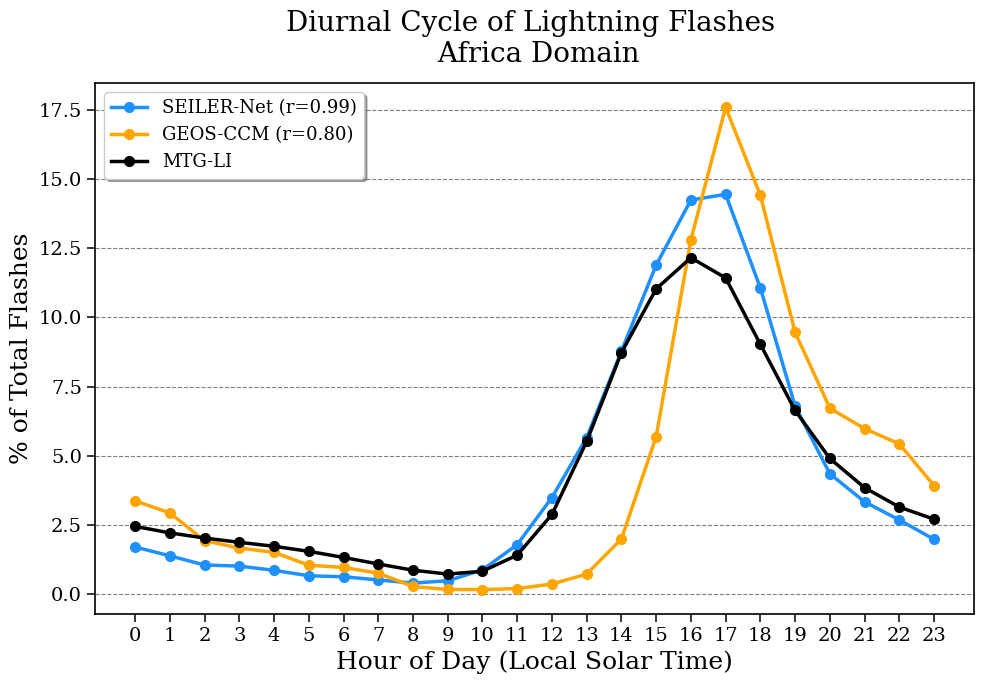

In [12]:
# ==============================================================================
# 1. COMPUTE REFERENCE (MTG) LOCAL DIURNAL CYCLE
# ==============================================================================
REF_NAME = "MTG-LI"

ref_series = np.zeros(24)
ref_v = local_shifted_models_africa[REF_NAME]["values"]

# This now broadcasts perfectly to (4132, 64, 64) because ref_v is (Datetime, Lat, Lon)
ref_hours_3d = np.broadcast_to(
    local_shifted_models_africa[REF_NAME]["local_hours"][:, np.newaxis, :], 
    ref_v.shape
)

for hour in range(24):
    ref_series[hour] = ref_v[ref_hours_3d == hour].sum()
ref_percent = 100 * ref_series / ref_series.sum()


# ==============================================================================
# 2. SET UP THE SINGLE PANEL FIGURE
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 7))


# ==============================================================================
# 3. LOOP THROUGH AND PLOT EACH MODEL
# ==============================================================================
for name, data in local_shifted_models_africa.items():
    hourly_series = np.zeros(24)
    v = data["values"]
    hours_3d = np.broadcast_to(data["local_hours"][:, np.newaxis, :], v.shape)
    
    for hour in range(24):
        hourly_series[hour] = v[hours_3d == hour].sum()
        
    percent_diurnal = 100 * hourly_series / hourly_series.sum()

    # Calculate Pearson correlation coefficient against MTG reference
    if name != REF_NAME:
        corr = np.corrcoef(percent_diurnal, ref_percent)[0, 1]
        label = f"{name} (r={corr:.2f})"
    else:
        label = name

    # Plot line with your preferred bold linewidth and markers
    ax.plot(
        range(0, 24), percent_diurnal, 
        marker='o', linewidth=2.5, markersize=7, 
        color=colors[name], label=label
    )

# ==============================================================================
# 4. GLOBAL FORMATTING & STYLING
# ==============================================================================
ax.set_xlabel("Hour of Day (Local Solar Time)", fontsize=18, fontfamily='serif')
ax.set_ylabel("% of Total Flashes", fontsize=18, fontfamily='serif')
ax.set_title("Diurnal Cycle of Lightning Flashes \n Africa Domain", fontsize=20, fontfamily='serif', pad=15)

ax.set_xticks(range(0, 24))
ax.tick_params(axis='both', labelsize=14)
ax.grid(axis='y', linestyle='--', alpha=1.0, color="gray")
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=13)

# ==============================================================================
# 5. EXPORT AND SHOW
# ==============================================================================
plt.tight_layout()

# Save the publication-quality figure to disk
plt.savefig("Africa_lightning_diurnal_cycle_single.pdf", dpi=300, bbox_inches="tight")
plt.show()

plt.close()

In [6]:
#Land Ocean Evaluation
#I need to get all the land grid cells from the USA in their own array. I need to do the same for the ocean. 
#Step 1. Take in the LWI data. 
africa_LWI = xr.open_dataset("/home/mseiler1/scratch.pickerin-prj/Data_Folder_All/Features/Africa_new/LWI_africa.nc")
africa_lwi = africa_LWI['lwi']

In [7]:
#Separating the Data: 
# land/ocean flag
flag = africa_lwi  # DataArray (Latitudes, Longitudes)
# Create boolean masks
land_mask  = flag >= 0.55
water_mask = flag < 0.55

In [9]:
#Apply the Mask to the JJ land:
regression_land_JJ = regression_JJ.where(land_mask)
MT1_land_JJ = MT1_JJ.where(land_mask)
MT2_land_JJ = MT2_JJ.where(land_mask)
lopez_land_JJ = lopez_JJ.where(land_mask)
glm_land_JJ = glm_JJ.where(land_mask)

regression_water_JJ = regression_JJ.where(water_mask)
MT1_water_JJ = MT1_JJ.where(water_mask)
MT2_water_JJ = MT2_JJ.where(water_mask)
lopez_water_JJ = lopez_JJ.where(water_mask)
glm_water_JJ = glm_JJ.where(water_mask)

# seiler_land_ON = seiler_ON.where(land_mask)
# lopez_land_ON = lopez_ON.where(land_mask)
# glm_land_ON = glm_ON.where(land_mask)

# seiler_water_ON = seiler_ON.where(water_mask)
# lopez_water_ON = lopez_ON.where(water_mask)
# glm_water_ON = glm_ON.where(water_mask)

NameError: name 'regression_JJ' is not defined

In [10]:
#Density Scatter Plots for Ocean and Land 
#List of models for prediction
models_pacific = [
      model1_unlogged_africa, # include Lopez & GLM
      africa_lopez
]

#Apply masks to create separate land and ocean datasets
models_land = [m.where(land_mask) for m in models_pacific]
models_ocean = [m.where(water_mask) for m in models_pacific]

In [11]:
# Sum over Latitudes and Longitudes to get total flashes per hour
# This will give one value per time step (hour) for each model

# For land
pred_totals_land = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_land]
# For ocean
pred_totals_ocean = [m.sum(dim=["Latitudes", "Longitudes"]) for m in models_ocean]
# Also do the same for the truth (GLM)
truth_total_land = africa_flash_MTG['flashes'].where(land_mask).sum(dim=["Latitudes", "Longitudes"])
truth_total_ocean = africa_flash_MTG['flashes'].where(water_mask).sum(dim=["Latitudes", "Longitudes"])

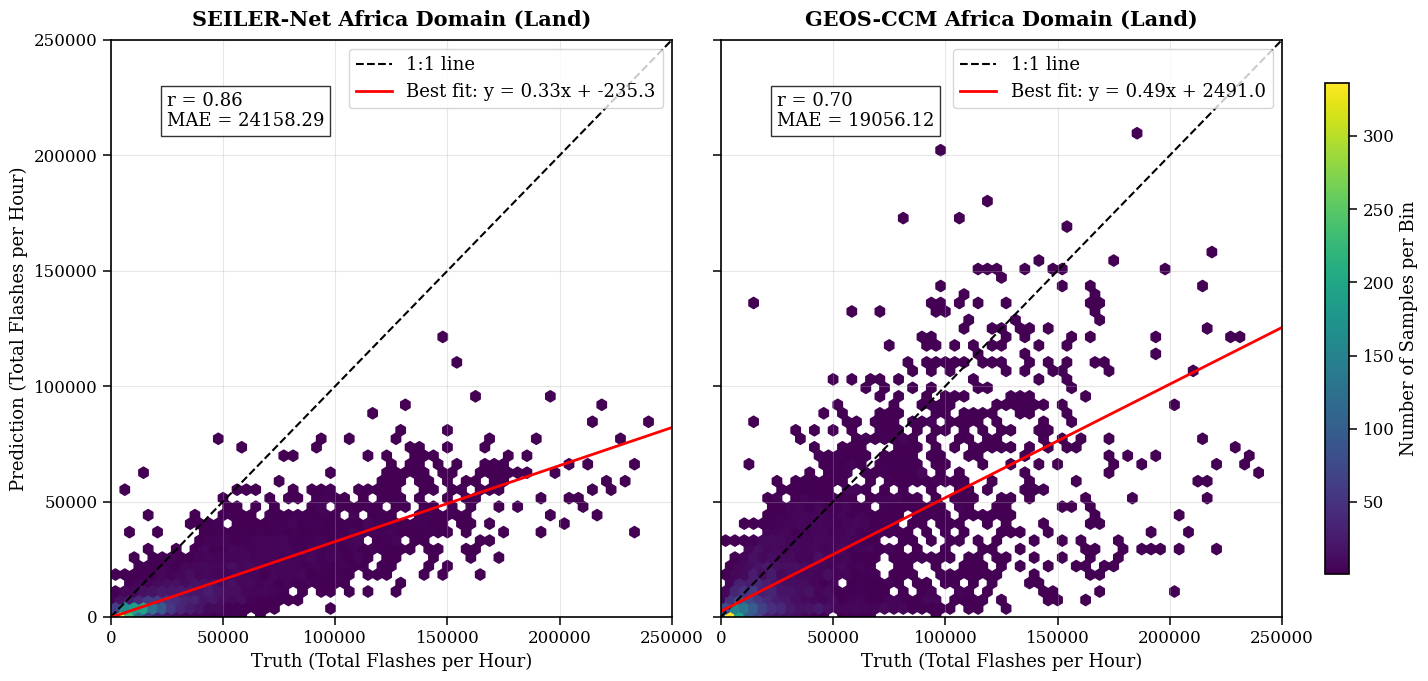

SEILER-Net R^2 value:  0.13452810049057007
GEOS Lopez R^2 value:  0.3360334038734436


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. Extract and Flatten the Pre-Summed Land Arrays
# ==============================================================================
# SEILER-Net is at index 0, GEOS Lopez is at index 1
seiler_land = pred_totals_land[0].values.ravel()
lopez_land  = pred_totals_land[1].values.ravel()

# Your reference truth array
truth_land  = truth_total_land.values.ravel()

# ==============================================================================
# 2. Compute Metrics for Both Panels
# ==============================================================================
# Panel 1: SEILER-Net vs Truth
r_seiler = np.corrcoef(truth_land, seiler_land)[0, 1]
mae_seiler = np.mean(np.abs(seiler_land - truth_land))

# Panel 2: GEOS Lopez vs Truth
r_lopez = np.corrcoef(truth_land, lopez_land)[0, 1]
mae_lopez = np.mean(np.abs(lopez_land - truth_land))

# ==============================================================================
# 3. Setup Side-by-Side Figure Layout
# ==============================================================================
xmax = 250000
ymax = 250000

# sharey=True links the vertical axes cleanly
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Apply global styling
plt.rcParams.update({'font.family': 'serif', 'axes.grid': True})
x_line = np.array([0, xmax])

# ------------------------------------------------------------------------------
# LEFT PANEL: SEILER-Net vs Truth
# ------------------------------------------------------------------------------
ax1.set_xlim(0, xmax)
ax1.set_ylim(0, ymax)

# Generate hexbin for SEILER
hb1 = ax1.hexbin(
    truth_land, seiler_land,
    gridsize=60, mincnt=1, cmap="viridis",
    extent=(0, xmax, 0, ymax)
)

# Reference identity line
ax1.plot([0, xmax], [0, ymax], 'k--', label="1:1 line")

# Linear Best Fit Line
m_s, b_s = np.polyfit(truth_land, seiler_land, 1)
ax1.plot(x_line, m_s * x_line + b_s, color="red", linewidth=2, 
         label=f"Best fit: y = {m_s:.2f}x + {b_s:.1f}")

# Descriptive Stats Floating Box
ax1.text(0.1 * xmax, 0.85 * ymax, f"r = {r_seiler:.2f}\nMAE = {mae_seiler:.2f}",
         fontsize=13, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

# Labeling
ax1.set_xlabel("Truth (Total Flashes per Hour)", fontsize=13)
ax1.set_ylabel("Prediction (Total Flashes per Hour)", fontsize=13)
ax1.set_title("SEILER-Net Africa Domain (Land)", fontsize=15, fontweight='bold', pad=10)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper right", fontsize=13)


# ------------------------------------------------------------------------------
# RIGHT PANEL: GEOS Lopez vs Truth
# ------------------------------------------------------------------------------
ax2.set_xlim(0, xmax)
ax2.set_ylim(0, ymax)

# Generate hexbin for Lopez
hb2 = ax2.hexbin(
    truth_land, lopez_land,
    gridsize=60, mincnt=1, cmap="viridis",
    extent=(0, xmax, 0, ymax)
)

# Reference identity line
ax2.plot([0, xmax], [0, ymax], 'k--', label="1:1 line")

# Linear Best Fit Line
m_l, b_l = np.polyfit(truth_land, lopez_land, 1)
ax2.plot(x_line, m_l * x_line + b_l, color="red", linewidth=2, 
         label=f"Best fit: y = {m_l:.2f}x + {b_l:.1f}")

# Descriptive Stats Floating Box
ax2.text(0.1 * xmax, 0.85 * ymax, f"r = {r_lopez:.2f}\nMAE = {mae_lopez:.2f}",
         fontsize=13, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

# Labeling
ax2.set_xlabel("Truth (Total Flashes per Hour)", fontsize=13)
ax2.set_title("GEOS-CCM Africa Domain (Land)", fontsize=15, fontweight='bold', pad=10)
ax2.grid(alpha=0.3)
ax2.legend(loc="upper right", fontsize=13)


# ==============================================================================
# 4. COLORBAR & EXPORT CLEANUP
# ==============================================================================
plt.tight_layout()

# Place a unified colorbar relative to both panel dimensions
cbar = fig.colorbar(hb2, ax=[ax1, ax2], location='right', pad=0.03, shrink=0.85)
cbar.set_label("Number of Samples per Bin", fontsize=13)

# Save high-res figure
plt.savefig("Africa_hexbin_comparison_land.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ==============================================================================
# 5. R² Diagnostics Terminal Output
# ==============================================================================
ss_tot = np.sum((truth_land - np.mean(truth_land))**2)

ss_res_seiler = np.sum((truth_land - seiler_land)**2)
R2_seiler = 1 - ss_res_seiler / ss_tot

ss_res_lopez = np.sum((truth_land - lopez_land)**2)
R2_lopez = 1 - ss_res_lopez / ss_tot

print("SEILER-Net R^2 value: ", R2_seiler)
print("GEOS Lopez R^2 value: ", R2_lopez)

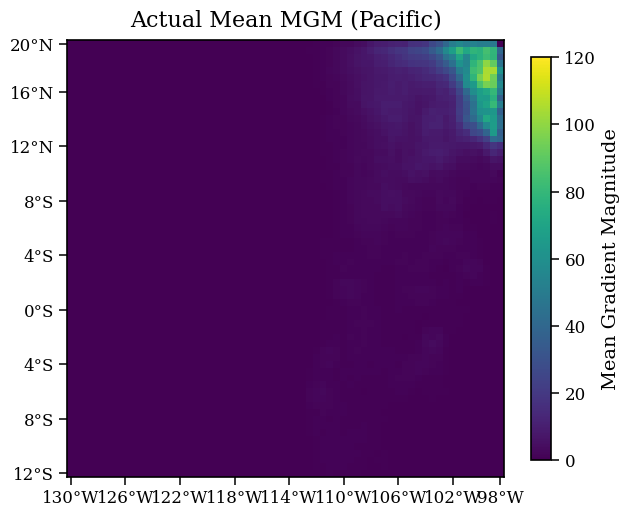

In [60]:
#MGM Plots 
import cv2

# --------------------------------------------------
# Models (xarray DataArrays: Datetime x Latitudes x Longitudes)
# --------------------------------------------------
models = [
    model1_unlogged_itcz,
    itcz_lopez_test,
    actual_unlogged_itcz
]

model_names = ["SEILER-Net", "Lopez", "Actual"]

# Optional: convert to float32 for memory efficiency
models_small = [m.astype(np.float32) for m in models]

# --------------------------------------------------
# Select which model to plot (0–3)
# --------------------------------------------------
model_idx = 2  # <-- change this index to select the model

model = models_small[model_idx]
model_name = model_names[model_idx]

# --------------------------------------------------
# Gradient magnitude function
# --------------------------------------------------
def gradient_magnitude(image):
    image = image.astype(float)
    grad_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    return np.sqrt(grad_x**2 + grad_y**2)

# --------------------------------------------------
# Compute average spatial gradient magnitude map
# --------------------------------------------------
grad_accum = np.zeros(
    (model.sizes["Latitudes"], model.sizes["Longitudes"]),
    dtype=np.float64
)

for i in range(model.sizes["Datetime"]):
    grad_accum += gradient_magnitude(
        model.isel(Datetime=i).values.squeeze()
    )

spatial_mgm_map = grad_accum / model.sizes["Datetime"]

# --------------------------------------------------
# Plot single figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5.5))

im = ax.imshow(
    spatial_mgm_map,
    origin="lower",
    cmap="viridis",
    vmax=120
)

ax.set_title(model_name, fontsize=13)
x_labels = ["130°W", "126°W", "122°W", "118°W", "114°W", "110°W", "106°W", "102°W", "98°W"]
y_labels = ["12°S", "8°S", "4°S", "0°S", "4°S", "8°S", "12°N", "16°N", "20°N"]

x_positions = [0, 8, 16, 24, 32, 40, 48, 56, 63]
y_positions = [0, 8, 16, 24, 32, 40, 48, 56, 63]

ax.set_xticks(x_positions)
ax.set_yticks(y_positions)

# Reverse only x-axis labels
ax.set_xticklabels(x_labels)
ax.set_yticklabels(y_labels)
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label("Mean Gradient Magnitude")
plt.title("Actual Mean MGM (Pacific)")
plt.tight_layout()
plt.show()


In [81]:
import cv2
# List of models
models = [
    model1_unlogged_itcz,
    itcz_lopez_test_predictions,
    actual_unlogged_itcz
]

model_names = ["SEILER-Net", "Lopez", "Actual"]

# Function to compute MGM for one image
def mean_gradient_magnitude(image):
    image = image.astype(float)
    grad_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    return np.mean(grad_mag)

# Compute a single MGM value per model
overall_mgm = []
for model in models:
    sample_mgms = []
    for i in range(model.sizes["Datetime"]):
        sample_image = model.isel(Datetime=i).values.squeeze()  # remove singleton dim
        sample_mgms.append(mean_gradient_magnitude(sample_image))
    # Average over all samples
    overall_mgm.append(np.mean(sample_mgms))

# Display
for name, mgm in zip(model_names, overall_mgm):
    print(f"{name}: Overall MGM = {mgm:.2f}")

SEILER-Net: Overall MGM = 1.11
Lopez: Overall MGM = 0.99
Actual: Overall MGM = 5.61
